In [162]:
from numpy import *
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler

In [163]:
# 生成对应alpha的下标
def selectJrand(i, m):
    j = i
    while (j == i):
        j = int(random.uniform(0, m))
    return j


# 使 aj在边界[L, H]内
def clipAlpha(aj, H, L):
    if aj > H:
        aj = H
    if L > aj:
        aj = L
    return aj

In [164]:
# SMO(序列最小优化)实现
def smoSimple(dataMatIn, classLabels, C, toler, maxIter):
    '''
    :param dataMatIn: 数据集
    :param classLabels: 类别标签
    :param C: 松弛变量
    :param toler: 容错率
    :param maxIter: 最大迭代次数
    '''
    dataMatrix = mat(dataMatIn)  # 转换为矩阵格式
    labelMat = mat(classLabels).transpose()  # 转换为列向量
    m, n = shape(dataMatrix)  # 获取数据集的行数和列数
    b = 0  # 初始化b
    alphas = mat(zeros((m, 1)))  # 初始化拉格朗日乘子
    iter = 0  # 初始化迭代次数
    while (iter < maxIter):  # 迭代次数小于最大迭代次数
        alphaPairsChanged = 0  # 初始化alpha对改变的次数
        for i in range(m):  # 遍历每一个样本
            fXi = float(multiply(alphas, labelMat).T * (dataMatrix * dataMatrix[i, :].T)) + b  # 计算f(xi)
            Ei = fXi - float(labelMat[i])  # 计算误差
            if ((labelMat[i] * Ei < -toler) and (alphas[i] < C)) or ((labelMat[i] * Ei > toler) and (alphas[i] > 0)):  # 判断是否需要优化
                j = selectJrand(i, m)  # 随机选择第二个alpha
                fXj = float(multiply(alphas, labelMat).T * (dataMatrix * dataMatrix[j, :].T)) + b  # 计算f(xj)
                Ej = fXj - float(labelMat[j])  # 计算误差
                alphaIold = alphas[i].copy()  # 保存旧的alpha值
                alphaJold = alphas[j].copy()  # 保存旧的alpha值
                if (labelMat[i] != labelMat[j]):  # 如果标签不同
                    L = max(0, alphas[j] - alphas[i])  # 设置上下界L和H
                    H = min(C, C + alphas[j] - alphas[i])
                else:  # 如果标签相同
                    L = max(0, alphas[i] + alphas[j] - C)  # 设置上下界L和H
                    H = min(C, alphas[i] + alphas[j])
                if L == H: continue  # 如果L等于H，跳过

                eta = -2.0 * dataMatrix[i, :] * dataMatrix[j, :].T + dataMatrix[i, :] * \
                dataMatrix[i, :].T + dataMatrix[j, :] * dataMatrix[j, :].T  # eta是核函数的导数

                if eta <= 0: continue  # 如果eta小于等于0，跳过

                alphas[j] += labelMat[j] * (Ei - Ej) / eta  # 更新alpha值
                alphas[j] = clipAlpha(alphas[j], H, L)  # 限制alpha值在上下界内
                alphas[i] += labelMat[j] * labelMat[i] * (alphaJold - alphas[j])  # 更新alpha值
                b1 = b - Ei - labelMat[i] * (alphas[i] - alphaIold) * dataMatrix[i, :] * dataMatrix[i, :].T\
                    - labelMat[j] * (alphas[j] - alphaJold) * dataMatrix[i, :] * dataMatrix[j, :].T
                b2 = b - Ej - labelMat[i] * (alphas[i] - alphaIold) * dataMatrix[i, :] * dataMatrix[j, :].T\
                    - labelMat[j] * (alphas[j] - alphaJold) * dataMatrix[j, :] * dataMatrix[j, :].T

                if (0 < alphas[i]) and (C > alphas[i]):  # 如果alpha值在(0, C)之间
                    b = b1
                elif (0 < alphas[j]) and (C > alphas[j]):  # 如果alpha值在(0, C)之间
                    b = b2
                else:  # 如果alpha值在边界上
                    b = (b1 + b2) / 2.0

                alphaPairsChanged += 1  # alpha对改变的次数加1
        if (alphaPairsChanged == 0):  # 如果没有alpha对改变，迭代次数加1
            iter += 1
        else:  # 如果有alpha对改变，迭代次数清零
            iter = 0
    return b, alphas  # 返回b和alphas

In [165]:
# 导入鸢尾花数据集
iris = datasets.load_iris()
x = iris.data
y = iris.target
X = x[y < 2,:2]     # 仅选择2个特征，方便绘图比较
y = y[y < 2]      # 仅选择2个类别，方便绘图比较

# 重置标签
y[y == 0] = -1

# 归一化
scaler = StandardScaler()
scaler.fit(X)  # 计算均值和标准差
X = scaler.transform(X)

# 保持为 NumPy 数组
dataMat, labelMat = X, y

# 设置参数
b, alphas = smoSimple(dataMat, labelMat, 1, 1e-5, 1000)  # 调用SMO算法

# 计算支持向量
w_best = np.multiply(alphas, labelMat).T @ dataMat  # 使用逐元素乘法

# 计算超平面、正例分类线和负例分类线
w0 = w_best[0, 0].item()
w1 = w_best[0, 1].item()
b_val = b.item()

plot_x = np.linspace(-3, 3, 200)  # 生成x坐标

lin_y = (-w0 * plot_x - b_val) / w1  # 超平面方程
up_y = (-w0 * plot_x + (1 - b_val)) / w1   # 正例间隔线
down_y = (-w0 * plot_x + (-1 - b_val)) / w1  # 负例间隔线

# 过滤条件：防止lin_y、up_y和down_y的值超出范围
line_index = (lin_y >= -3) & (lin_y <= 3)
up_index = (up_y >= -3) & (up_y <= 3)
down_index = (down_y >= -3) & (down_y <= 3)

# 将 matrix 转为 array， 并展平
up_y = np.array(up_y).flatten()
down_y = np.array(down_y).flatten()

# up_index = up_index.A
# up_index = up_index.flatten()
# down_index = down_index.A
# down_index = down_index.flatten()

C:\temp\ipykernel_10004\156377491.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fXi = float(multiply(alphas, labelMat).T * (dataMatrix * dataMatrix[i, :].T)) + b  # 计算f(xi)
C:\temp\ipykernel_10004\156377491.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ei = fXi - float(labelMat[i])  # 计算误差
C:\temp\ipykernel_10004\156377491.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fXj = float(multiply(alphas, labelMat).T * (dataMatrix * dataMatrix[j, :].T))

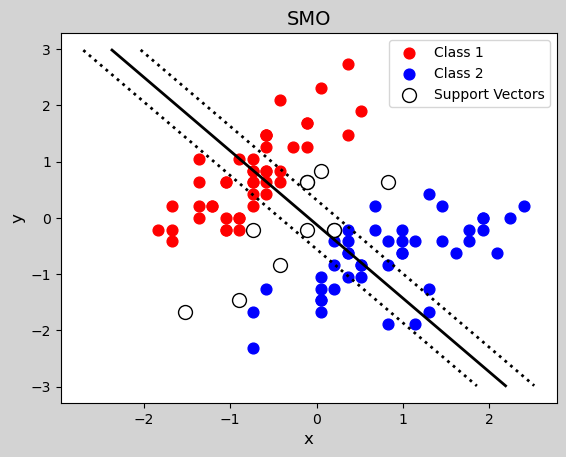

In [168]:
# 结果可视化
plt.figure('SMO', facecolor='lightgray')
plt.title('SMO', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.tick_params(labelsize=10)

# 绘制分类线
plt.plot(plot_x[up_index], up_y[up_index], c='black', linewidth = 2, linestyle=':')
plt.plot(plot_x[down_index], down_y[down_index], c='black', linewidth = 2, linestyle=':')
plt.plot(plot_x[line_index], lin_y[line_index], c='black', linewidth = 2, linestyle='-')

# 绘制支持向量
plt.scatter(X[y==-1, 0], X[y==-1, 1], s=60, c='red', marker='o', label='Class 1')
plt.scatter(X[y==1, 0], X[y==1, 1], s=60, c='blue', marker='o', label='Class 2')

plt.scatter(X[alphas.A.flatten() > 0, 0], X[alphas.A.flatten() > 0, 1], s=100, facecolor='white', edgecolor='black', label='Support Vectors')
plt.legend()
plt.show()